# Transfer Learning y Fine-Tuning: Configurando el Entorno y el Modelo

### De usar herramientas pre-entrenadas a adaptarlas

La semana pasadan: spaCy nos daba vectores, TextBlob nos daba una polaridad, Gensim encontraba topicos. Casi no entrenamos nada; solo consumimos lo que esas herramientas ya sabian hacer.

Esta semana damos un paso mas: vamos a **modificar los pesos de una red neuronal pre-entrenada** para que aprenda nuestra tarea especifica. A este proceso se lo llama **fine-tuning**, y es una aplicacion de una idea mas general llamada **transfer learning**: tomar un modelo entrenado para un problema (en este caso, entender lenguaje en general) y reusarlo como punto de partida para un problema relacionado pero distinto (en nuestro caso, clasificar el sentimiento de un tweet).

### El mismo dataset, un uso distinto

Vamos a seguir trabajando sobre los tweets de clientes de aerolineas que ya conocemos. Pero hay un cambio importante: la semana pasada, la etiqueta "verdadera" de cada tweet (puesta por personas) la usamos solamente para *comparar* que tan bien le iba a TextBlob. Nunca la usamos para entrenar nada, porque TextBlob no aprende de datos.

Esta semana, esa etiqueta pasa a ser el corazon del ejercicio: vamos a **entrenar** un modelo para que la prediga.

### El plan de este notebook

Hoy nos enfocamos en preparar el terreno:

1. Instalar y cargar las herramientas de Hugging Face.
2. Cargar un modelo BERT pre-entrenado junto con su tokenizador.
3. Entender como tokeniza BERT, y comprobar que la "cabeza" de clasificacion todavia no sabe nada (porque nunca la entrenamos).
4. Retomar el dataset de tweets, esta vez prestando atencion a la etiqueta que vamos a usar para entrenar.

## 0. Preparando el entorno

Necesitamos tres librerias de Hugging Face: `transformers` (modelos y tokenizadores), `datasets` (para manejar datasets de forma eficiente, la vamos a usar en el proximo notebook) y `accelerate` (que el `Trainer` usa por detras para manejar el entrenamiento, incluso en una sola maquina).

In [1]:
!pip install transformers datasets accelerate

In [2]:
import re

import pandas as pd
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

## 1. Cargando el tokenizador y el modelo pre-entrenado

Vamos a usar `bert-base-multilingual-cased`: una version de BERT entrenada sobre texto en mas de 100 idiomas (la version "cased" distingue mayusculas de minusculas). Es el modelo que vamos a ajustar (fine-tunear) para nuestra tarea.

Como nuestra tarea tiene 3 categorias posibles (Positivo, Neutral, Negativo), le decimos al modelo `num_labels=3` al cargarlo. Esto agrega automaticamente una capa de clasificacion nueva encima de BERT, del tamaño correcto para nuestro problema.

In [3]:
model_name = "bert-base-multilingual-cased"

# Cargamos el tokenizador correspondiente al modelo (se encargará de convertir el texto en los tokens e IDs que BERT necesita)
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Cargamos BERT preparado para clasificacion de textos
# num_labels=3 indica que nuestro problema tiene 3 categorias posibles
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3
)

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  714MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Es esperable que al ejecutar la celda anterior aparezca una advertencia (warning) diciendo algo como *"Some weights of BertForSequenceClassification were not initialized..."*. No es un error: nos esta avisando exactamente lo que esperabamos. BERT trae sus pesos pre-entrenados, pero la capa de clasificacion que agregamos arriba es nueva y arranca con pesos al azar. Todavia no sabe nada sobre sentimiento de tweets; eso es justamente lo que vamos a entrenar en los proximos notebooks.



```
                 ANTES DEL FINE-TUNING

        Texto
          │
          ▼
   ┌───────────────┐
   │     BERT      │  ← pesos pre-entrenados
   │  🧠🧠🧠🧠🧠    │
   └───────┬───────┘
           │
           ▼
   ┌───────────────┐
   │ Clasificador  │  ← 🎲 pesos al azar
   │   Neg/Neu/Pos │
   └───────────────┘
```


                 DURANTE EL FINE-TUNING

        Tweets etiquetados
                 │
                 ▼
        ┌─────────────────┐
        │ BERT +          │
        │ clasificador    │
        └────────┬────────┘
                 │
                 ▼
          se ajustan los
             pesos


                 DESPUÉS

        ┌───────────────┐
        │     BERT      │  ← conocimiento del lenguaje
        └───────┬───────┘
                │
                ▼
        ┌───────────────┐
        │ Clasificador  │  ← ahora aprendió
        │ Neg / Neu / Pos│     sentimiento
        └───────────────┘


BERT ya trae conocimientos sobre el lenguaje gracias a su pre-entrenamiento. La capa de clasificación es nueva y empieza con pesos aleatorios. Durante el fine-tuning, usamos nuestros tweets etiquetados para ajustar el modelo y enseñarle a distinguir entre las categorías de sentimiento.

## 2. Como tokeniza BERT

BERT no usa el mismo tipo de tokenizacion que vimos con spaCy. Usa **WordPiece**, una tecnica parecida al BPE (que programamos a mano): en vez de un token por palabra, las palabras menos frecuentes se parten en pedazos mas chicos.

Probemos con una oracion de ejemplo.

In [4]:
oracion_ejemplo = "The flight was cancelled and nobody explained why. We've lost all our great vacacion plans."

encoding = tokenizer(oracion_ejemplo)
tokens = tokenizer.convert_ids_to_tokens(encoding["input_ids"])

print(tokens)

['[CLS]', 'The', 'flight', 'was', 'cancelled', 'and', 'no', '##body', 'explained', 'why', '.', 'We', "'", 've', 'lost', 'all', 'our', 'great', 'va', '##ca', '##cion', 'plans', '.', '[SEP]']


Fijate si alguna palabra aparece partida en dos o mas pedazos (los pedazos que no son el inicio de una palabra empiezan con `##`). Como este modelo es multilingue -- su vocabulario esta repartido entre mas de 100 idiomas, no solo ingles -- es normal que parta mas palabras en pedazos de lo que lo haria un BERT entrenado unicamente en ingles. Es el mismo tipo de compromiso (vocabulario mas chico y compartido vs. tokens mas largos y especificos) que vimos al comparar BPE, WordPiece y Unigram LM.

Tambien vas a ver los tokens especiales `[CLS]` al principio y `[SEP]` al final: BERT los necesita para saber donde empieza y termina cada secuencia.

## 3. Una cabeza de clasificacion que todavia no sabe nada

Comprobemos lo que decia la advertencia de antes: si le pasamos un tweet al modelo tal cual esta ahora, sin haberlo entrenado, la prediccion deberia ser mas o menos al azar.

In [5]:
tweet_ejemplo = "This was the worst flight experience I have ever had."

# Tokenizamos el texto y lo convertimos directamente en tensores de PyTorch
encoding = tokenizer(tweet_ejemplo, return_tensors="pt") # return_tensors="pt" indica que queremos tensores compatibles con PyTorch

# Desactivamos el calculo de gradientes porque en este momento
# solo queremos hacer una prediccion, no entrenar el model
with torch.no_grad():
    salida = model(**encoding) # Pasamos los tokens ('encoding') por BERT para obtener la prediccion

# BERT devuelve logits: valores sin convertir en probabilidades
# softmax transforma esos valores en probabilidades que suman 1
probabilidades = torch.softmax(salida.logits, dim=-1)

print("Logits:", salida.logits)
print("Probabilidades:", probabilidades)

Logits: tensor([[ 0.1536, -0.1630, -0.0458]])
Probabilidades: tensor([[0.3925, 0.2860, 0.3215]])


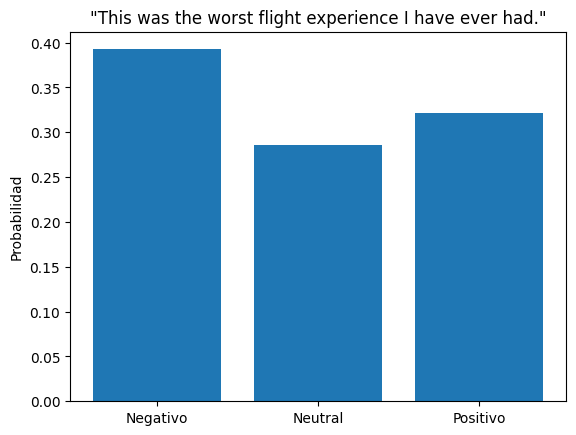

In [12]:
import matplotlib.pyplot as plt
plt.bar(["Negativo", "Neutral", "Positivo"], probabilidades[0].numpy())
plt.title(f'"{tweet_ejemplo}"')
plt.ylabel("Probabilidad")
plt.show()

Aunque el tweet es claramente negativo, las probabilidades que devuelve el modelo no tienen por que reflejar eso: la capa de clasificacion nunca vio un ejemplo etiquetado, asi que sus pesos son practicamente aleatorios. Esta es la brecha que vamos a cerrar entrenando: BERT ya sabe "entender" ingles (eso viene del pre-entrenamiento), pero todavia no sabe como traducir ese entendimiento en una prediccion de sentimiento util para nosotros.

## 4. Retomando el dataset de tweets

Volvemos a cargar el dataset de tweets sobre aerolineas y aplicamos la misma limpieza liviana que usamos la semana pasada (sacar menciones y links, sin tocar el resto de la oracion).

In [ ]:
url_dataset = "https://raw.githubusercontent.com/Camille-Le-Roy/data_analytics_resources/main/Datasets/Tweets_Airlines.csv"

columnas_utiles = ["tweet_id", "airline", "text", "airline_sentiment"]
df = pd.read_csv(url_dataset, usecols=columnas_utiles)
df = df.rename(columns={
    "tweet_id": "id",
    "airline": "aerolinea",
    "text": "texto",
    "airline_sentiment": "sentimiento_original",
})


def quitar_menciones_y_links(texto):
    texto = re.sub(r"@\w+", "", texto)
    texto = re.sub(r"http\S+", "", texto)
    return texto.strip()


df["texto_sentimiento"] = df["texto"].apply(quitar_menciones_y_links)
df.head()

,id,sentimiento_original,aerolinea,texto,texto_sentimiento
0,570306133677760513,neutral,Virgin America,@VirginAmerica What @dhepburn said.,What said.
1,570301130888122368,positive,Virgin America,@VirginAmerica plus you've added commercials t...,plus you've added commercials to the experienc...
2,570301083672813571,neutral,Virgin America,@VirginAmerica I didn't today... Must mean I n...,I didn't today... Must mean I need to take ano...
3,570301031407624196,negative,Virgin America,@VirginAmerica it's really aggressive to blast...,"it's really aggressive to blast obnoxious ""ent..."
4,570300817074462722,negative,Virgin America,@VirginAmerica and it's a really big bad thing...,and it's a really big bad thing about it


## 5. La etiqueta que vamos a usar para entrenar

La semana pasada, `sentimiento_original` era solo una referencia para chequear que tan bien le iba a TextBlob. Esta vez la vamos a usar de verdad: es la etiqueta que le vamos a pedir a BERT que aprenda a predecir.

In [ ]:
df["sentimiento_original"].value_counts()

,count
sentimiento_original,
negative,9178
neutral,3099
positive,2363


Guardemos este dataset asi lo tenemos a mano al empezar el proximo notebook.

In [ ]:
df.to_csv("feedback_aerolineas_para_bert.csv", index=False)
print("Guardado. Filas:", len(df))

Guardado. Filas: 14640


## Resumen

- **Transfer learning**: reusar un modelo entrenado para una tarea (entender lenguaje en general) como punto de partida para otra tarea relacionada (clasificar sentimiento).
- **Fine-tuning**: el proceso de seguir entrenando (una parte de) ese modelo sobre nuestros propios datos etiquetados.
- BERT usa **WordPiece** para tokenizar, con el mismo espiritu que BPE pero con su propia forma de elegir que fusionar.
- Con `num_labels=3` conseguimos una capa de clasificacion nueva, pero sus pesos son aleatorios hasta que la entrenemos: por eso las predicciones de ahora no tienen sentido todavia.
- Esta semana `sentimiento_original` deja de ser solo una referencia y pasa a ser la etiqueta que usamos para entrenar.

En el proximo notebook preparamos el dataset completo para el entrenamiento (tokenizacion en lote, separacion en train/test) e implementamos la parte central del transfer learning: congelar las capas de BERT para entrenar unicamente la cabeza de clasificacion.